In [1]:
import os, glob, shutil, zipfile, gdown
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorboard as tb
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses
%matplotlib inline

# Load the TensorBoard notebook extension
%load_ext tensorboard

# metrics
from sklearn import metrics

In [ ]:
# Global Variables
FILE_ID = "1FOpBqxqZRkAkv1rlTPw1ZLME1wG_tJOv"
tf.keras.utils.set_random_seed(200)
height, width = 128, 128
channels = 3

In [3]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")
    
    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

In [4]:
def download_and_prep_dataset(FILE_ID):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "../dataSet/cloth_dataSet_small.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "../unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "../dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "../dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)
    
    # Load the dataset
    data_path = os.path.join(extractPath, "clothing-dataset-small")
    return data_path

def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

In [5]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)
print(dl_ext_data_path)

# Check the dataset Paths
train_path = os.path.join(dl_ext_data_path, "train")
test_path = os.path.join(dl_ext_data_path, "test")
val_path = os.path.join(dl_ext_data_path, "validation")

assert os.path.exists(train_path), "Train path does not exist"
assert os.path.exists(test_path), "Test path does not exist"
assert os.path.exists(val_path), "Val path does not exist"

# Load the dataset
Train_DS = tf.keras.utils.image_dataset_from_directory(directory=train_path, shuffle=True, label_mode="categorical")
Test_DS = tf.keras.utils.image_dataset_from_directory(directory=test_path, shuffle=True, label_mode="categorical")
Val_DS = tf.keras.utils.image_dataset_from_directory(directory=val_path, shuffle=True, label_mode="categorical")

# Scale the DataSet
Train_scaled, Test_scaled, Val_scaled = preprocess(Train_DS, Val_DS, Test_DS, target_height=height, target_width=width)
classNames = Train_DS.class_names

CWD:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks
c:\Study\gitRepo\CV_Amazon_Cloth_Classify\unzipLoc\clothing-dataset-small
Found 3068 files belonging to 10 classes.
Found 372 files belonging to 10 classes.
Found 341 files belonging to 10 classes.


In [43]:
def plot_training_history(history):
    trainAcc = history.history["accuracy"]
    valAcc = history.history["val_accuracy"]

    trainLoss = history.history["loss"]
    valLoss = history.history["val_loss"]

    # Plot the Training and Validation Accuracy
    plt.rcParams['legend.fontsize'] = 'x-small'
    fig, ax = plt.subplots(ncols=2, nrows=1)
    fig.set_figheight(4)
    fig.set_figwidth(8)
    ax[0].plot(trainAcc, label="Training Accuracy")
    ax[0].plot(valAcc, label="Validation Accuracy")
    ax[0].set_title("Training and Validation Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].set_ylabel("Accuracy")
    
    ax[0].legend()

    # Plot the Training and Validation Loss
    ax[1].plot(trainLoss, label="Training Loss")
    ax[1].plot(valLoss, label="Validation Loss")
    ax[1].set_title("Training and Validation Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.show()

# function to print the accuracy stats
def calculate_multiclass_metrics(model, test_ds, num_classes):
    """
    Calculate metrics for multi-class classification using sklearn metrics
    
    Args:
        model: Trained Keras model
        test_ds: Test dataset (tf.data.Dataset)
        num_classes: Number of classes
    Returns:
        Dictionary containing calculated metrics
    """
    # Get true labels and predictions
    y_true = []
    y_pred = []
    y_pred_proba = []

    # Collect predictions and true labels
    for x, y in test_ds:
        predictions = model.predict(x, verbose=0)
        y_true.append(tf.argmax(y, axis=1))
        y_pred.append(tf.argmax(predictions, axis=1))
        y_pred_proba.append(predictions)

    # Convert to numpy arrays
    y_true = tf.concat(y_true, axis=0).numpy()
    y_pred = tf.concat(y_pred, axis=0).numpy()
    y_pred_proba = tf.concat(y_pred_proba, axis=0).numpy()

    # Calculate metrics
    metrics_dict = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted'),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

    # Print results
    print("\nTest Metrics:")
    print(f"Accuracy: {metrics_dict['accuracy']:.4f}")
    print(f"\nMacro-averaged metrics:")
    print(f"Precision: {metrics_dict['precision_macro']:.4f}")
    print(f"Recall: {metrics_dict['recall_macro']:.4f}")
    print(f"F1-score: {metrics_dict['f1_macro']:.4f}")
    
    print(f"\nWeighted-averaged metrics:")
    print(f"Precision: {metrics_dict['precision_weighted']:.4f}")
    print(f"Recall: {metrics_dict['recall_weighted']:.4f}")
    print(f"F1-score: {metrics_dict['f1_weighted']:.4f}")

    # Print classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(metrics_dict['confusion_matrix'], 
                annot=True, 
                fmt='d',
                cmap='Blues')
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # Plot ROC curves for each class
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true == i, y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.show()

    return metrics_dict

# Required imports
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Usage:
"""
testModel = tf.keras.models.load_model(ModelBestsave)
metrics = calculate_multiclass_metrics(testModel, Test_scaled, num_classes=10)

# Access specific metrics
print(f"Accuracy: {metrics['accuracy']}")
print(f"Macro F1: {metrics['f1_macro']}")
"""

# Optional: Add timing decorator
def timer_decorator(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        print(f"\nExecution time: {end_time - start_time:.2f} seconds")
        return result
    return wrapper

@timer_decorator
def calculate_multiclass_metrics_with_timing(model, test_ds, num_classes):
    return calculate_multiclass_metrics(model, test_ds, num_classes)

# Usage with timing:
"""
metrics = calculate_multiclass_metrics_with_timing(testModel, Test_scaled, num_classes=10)
"""

# Add function to plot prediction distribution
def plot_prediction_distribution(y_pred_proba):
    plt.figure(figsize=(10, 6))
    plt.hist(np.max(y_pred_proba, axis=1), bins=50)
    plt.title('Distribution of Prediction Probabilities')
    plt.xlabel('Maximum Prediction Probability')
    plt.ylabel('Count')
    plt.show()

# Add function to show misclassified examples
def show_misclassified_examples(model, test_ds, class_names, num_examples=5):
    misclassified = []
    
    for x, y in test_ds:
        predictions = model.predict(x, verbose=0)
        pred_classes = tf.argmax(predictions, axis=1)
        true_classes = tf.argmax(y, axis=1)
        
        # Find misclassified indices
        incorrect = tf.where(pred_classes != true_classes)
        
        for idx in incorrect:
            misclassified.append({
                'image': x[idx],
                'true': true_classes[idx].numpy(),
                'pred': pred_classes[idx].numpy(),
                'confidence': predictions[idx][pred_classes[idx]].numpy()
            })
            
        if len(misclassified) >= num_examples:
            break
    
    # Plot misclassified examples
    fig, axes = plt.subplots(1, min(num_examples, len(misclassified)), 
                            figsize=(15, 3))
    for i, example in enumerate(misclassified[:num_examples]):
        axes[i].imshow(example['image'])
        axes[i].set_title(f'True: {class_names[example["true"]]}\n'
                         f'Pred: {class_names[example["pred"]]}\n'
                         f'Conf: {example["confidence"]:.2f}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


# start training the model
def start_model_training(model, train_data, val_data, epochs=10, model_name="base_model",
                            useCSVLogger=False, useTensorBoard=False, modelChkpoint=False, earlyStopping=False, lrScheduler=False):

    logName = ""
    tensorBoardLogs = ""
    mdkCkhPointfilepath = ""

    model.compile(optimizer=optimizers.Adam(),
                loss=losses.CategoricalCrossentropy(),
                metrics=["accuracy"])
    callbackslist = []        
    if useCSVLogger:
        logName = generate_logs_Name(fileName=model_name, logFormat=".log", clear_folder=False)
        csvLogger = callbacks.CSVLogger(filename=logName)
        callbackslist.append(csvLogger)
    
    if useTensorBoard:
        tensorBoardLogs = generate_logs_Folder(logfolderName=model_name+"_tb_logs", clear_folder=False)
        tensorBoard = callbacks.TensorBoard(log_dir=tensorBoardLogs, histogram_freq=1)
        callbackslist.append(tensorBoard)
    
    if modelChkpoint:
        modelChkpointLoc = generate_logs_Folder(logfolderName="model_save", clear_folder=False)
        mdkCkhPointfilepath = os.path.join(modelChkpointLoc, model_name+"_best_model.keras")
        modelCheckpoint = callbacks.ModelCheckpoint(filepath=mdkCkhPointfilepath,
                                                    save_best_only=True,
                                                    save_weights_only=False,
                                                    monitor="val_loss",
                                                    mode="min")
        callbackslist.append(modelCheckpoint)

    if earlyStopping:
        earlyStopping = callbacks.EarlyStopping(monitor="val_accuracy", patience=5, mode="max")
        callbackslist.append(earlyStopping)
    
    if lrScheduler:
        lrdecay = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=0.0001)
        callbackslist.append(lrdecay)

    # start the model Training
    history = model.fit(train_data,
                        validation_data=val_data,
                        epochs=epochs,
                        callbacks=callbackslist,
                        verbose=1)
    return history , (logName, tensorBoardLogs, mdkCkhPointfilepath)

#### Create Base Model

In [7]:
## Create CNN Model
# Base Line Model
def create_base_model(model_name="cnn_Model"):

    #input Layer
    inpLayer = layers.Input(shape=(height, width, channels))

    # Convolutional Layer
    conv2D_1 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu') (inpLayer)
    maxPool_1 = layers.MaxPooling2D() (conv2D_1)
    
    # Flatten Layer
    flatten = layers.Flatten() (maxPool_1)

    # Dense Layer
    dense_1 = layers.Dense(units=128, activation='relu') (flatten)

    # Output Layer
    output = layers.Dense(units=len(classNames), activation='softmax') (dense_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

In [8]:
modelName="base_model"

# create Model
baseModel = create_base_model(model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(baseModel, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=baseModel,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=15,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 163ms/step - accuracy: 0.2689 - loss: 4.8722 - val_accuracy: 0.2473 - val_loss: 2.1159 - learning_rate: 0.0010
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.5164 - loss: 1.5061 - val_accuracy: 0.4140 - val_loss: 1.7441 - learning_rate: 0.0010
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 16s 162ms/step - accuracy: 0.6856 - loss: 1.0460 - val_accuracy: 0.4839 - val_loss: 1.6609 - learning_rate: 0.0010
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - accuracy: 0.8121 - loss: 0.6491 - val_accuracy: 0.5108 - val_loss: 1.5943 - learning_rate: 0.0010
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 17s 173ms/step - accuracy: 0.8936 - loss: 0.4234 - val_accuracy: 0.5349 - val_loss: 1.5087 - learning_rate: 0.0010
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 140ms/step - accuracy: 0.9479 - loss: 0.2496 - val_accuracy: 0.5296 - val_loss: 1.5517 - learning_rate: 0.0010
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - accuracy: 0.9715 - loss: 0.

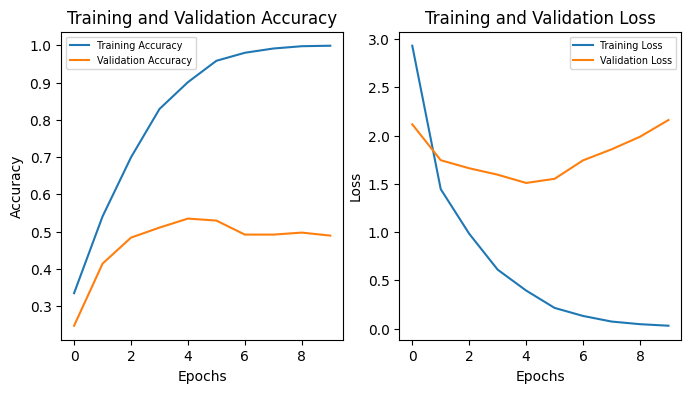

In [9]:
# Plot the Training History
plot_training_history(history)

In [ ]:
trainingCSV, tensorBoardLogs, ModelBestsave = trainingLogPath
print("Training csv Logs: ", trainingCSV)
print("TensorBoard Logs: ", tensorBoardLogs)
print("Model Best Save: ", ModelBestsave)

model = tf.keras.models.load_model(ModelBestsave)
calculate_multiclass_metrics(model=model, ds=Test_scaled, class_names=classNames, typeOfData="Test")

Training csv Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_20250223-170750\deep_Gap_BN_DP_Reg_model_20250223-170750.log
TensorBoard Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_tb_logs_20250223-170750
Model Best Save:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\model_save_20250223-170750\deep_Gap_BN_DP_Reg_model_best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

Train Metrics:
Accuracy: 14.41%
Precision: 0.14
Recall: 0.14
F1 Score: 0.14

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Validation Metrics:
Accuracy: 13.17%
Precision: 0.14
Recall: 0.13
F1 Score: 0.13

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Test Metrics:
Accuracy: 14.08%
Precision: 0.14
Recall: 0.14
F1 Score: 0.14



#### Insights from base model
The model is quite over fitting.

Techniques to reduce overfitting.
1) L1/L2 regularization
2) Dropout
3) Learning Rate scheduler
4) Model Architecture (make it simpler)
5) GAP (CNN specific)

#### Adding GAP layer and make model deeper

In [11]:
# Gap_Deep Model
def create_deep_gap_model(model_name="cnn_Model"):

    # Input Layer
    inpLayer = layers.Input(shape=(height, width, channels))
    
    # Convolutional Layer 1
    conv2D_1 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same", activation='relu') (inpLayer)
    maxPool_1 = layers.MaxPooling2D() (conv2D_1)
    
    # Convolutional Layer 2
    conv2D_2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_1)
    maxPool_2 = layers.MaxPooling2D() (conv2D_2)
    
    # Convolutional Layer 3
    conv2D_3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_2)
    maxPool_3 = layers.MaxPooling2D() (conv2D_3)

    # Convolutional Layer 4
    conv2D_4 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_3)
    maxPool_4 = layers.MaxPooling2D() (conv2D_4)

    # Convolutional Layer 5
    conv2D_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation='relu') (maxPool_4)
    maxPool_5 = layers.MaxPooling2D() (conv2D_5)

    # Global Average Pooling Layer
    gapLayer = layers.GlobalAveragePooling2D() (maxPool_5)

    # Dense Layer
    dense_1 = layers.Dense(units=256, activation='relu') (gapLayer)

    # Output Layer
    output = layers.Dense(units=len(classNames), activation='softmax') (dense_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

In [12]:
modelName="deep_gap_model"

# create Model
deep_gap_model = create_deep_gap_model(model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(deep_gap_model, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=deep_gap_model,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=15,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.2426 - loss: 2.1635 - val_accuracy: 0.1398 - val_loss: 2.3636 - learning_rate: 0.0010
Epoch 2/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.2900 - loss: 2.0767 - val_accuracy: 0.1801 - val_loss: 2.2729 - learning_rate: 0.0010
Epoch 3/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.3580 - loss: 1.9442 - val_accuracy: 0.2554 - val_loss: 2.1116 - learning_rate: 0.0010
Epoch 4/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.3954 - loss: 1.8009 - val_accuracy: 0.3306 - val_loss: 1.9104 - learning_rate: 0.0010
Epoch 5/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.4596 - loss: 1.6262 - val_accuracy: 0.3118 - val_loss: 1.7912 - learning_rate: 0.0010
Epoch 6/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.5007 - loss: 1.5051 - val_accuracy: 0.4624 - val_loss: 1.5099 - learning_rate: 0.0010
Epoch 7/15
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5350 - loss: 1.3595 - val_acc

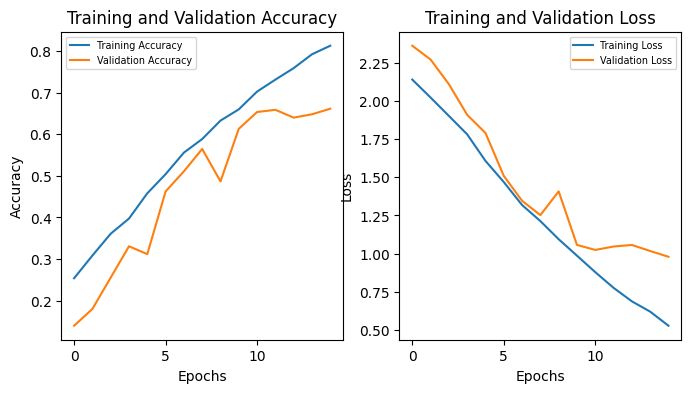

In [13]:
# Plot the Training History
plot_training_history(history)

In [27]:
trainingCSV, tensorBoardLogs, ModelBestsave = trainingLogPath
print("Training csv Logs: ", trainingCSV)
print("TensorBoard Logs: ", tensorBoardLogs)
print("Model Best Save: ", ModelBestsave)

print_accuracy_stats(model=ModelBestsave, ds=Train_scaled, class_names=classNames, typeOfData="Train")
print_accuracy_stats(model=ModelBestsave, ds=Val_scaled, class_names=classNames, typeOfData="Validation")
print_accuracy_stats(model=ModelBestsave, ds=Test_scaled, class_names=classNames, typeOfData="Test")

Training csv Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_20250223-170750\deep_Gap_BN_DP_Reg_model_20250223-170750.log
TensorBoard Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_tb_logs_20250223-170750
Model Best Save:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\model_save_20250223-170750\deep_Gap_BN_DP_Reg_model_best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

Train Metrics:
Accuracy: 13.40%
Precision: 0.13
Recall: 0.13
F1 Score: 0.13

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Validation Metrics:
Accuracy: 13.98%
Precision: 0.14
Recall: 0.14
F1 Score: 0.14

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Test Metrics:
Accuracy: 13.20%
Precision: 0.13
Recall: 0.13
F1 Score: 0.13



#### Insights from Deep CVV with GAP layer
We can se that the model is learing useful information but overfitting a lot

Techniques to reduce overfitting for next model.
1) Batch Normalization
2) Dropout

#### model with added regulisations - Batch Normalization, Drop out

In [15]:
## Adding Batch normalization and Drop out to the model.

# Gap_Deep Model
def create_deep_gap_bn_dp_model(model_name="cnn_Model"):
    inpLayer = layers.Input(shape=(height, width, channels))
    # conv unit 1
    conv2D_1 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same") (inpLayer)
    actReli_1 = layers.Activation("relu") (conv2D_1)
    bn_1 = layers.BatchNormalization() (actReli_1)
    maxPool_1 = layers.MaxPooling2D() (bn_1)
 
    # conv unit 2
    conv2D_2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same") (maxPool_1)
    actReli_2 = layers.Activation("relu") (conv2D_2)
    bn_2 = layers.BatchNormalization() (actReli_2)
    maxPool_2 = layers.MaxPooling2D() (bn_2)

    # conv unit 3
    conv2D_3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same") (maxPool_2)
    actReli_3 = layers.Activation("relu") (conv2D_3)
    bn_3 = layers.BatchNormalization() (actReli_3)
    maxPool_3 = layers.MaxPooling2D() (bn_3)

    # conv unit 4
    conv2D_4 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same") (maxPool_3)
    actReli_4 = layers.Activation("relu") (conv2D_4)
    bn_4 = layers.BatchNormalization() (actReli_4)
    maxPool_4 = layers.MaxPooling2D() (bn_4)

    # conv unit 5
    conv2D_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), padding="same") (maxPool_4)
    actReli_5 = layers.Activation("relu") (conv2D_5)
    bn_5 = layers.BatchNormalization() (actReli_5)
    maxPool_5 = layers.MaxPooling2D() (bn_5)

    # Global Average Pooling
    gapLayer = layers.GlobalAveragePooling2D() (maxPool_5)

    # Dense Layers
    dense_1 = layers.Dense(units=256, activation='relu') (gapLayer)
    bn_6 = layers.BatchNormalization() (dense_1)
    dropOut_1 = layers.Dropout(0.3) (bn_6)

    # output layer
    output = layers.Dense(units=len(classNames), activation='softmax') (dropOut_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

In [16]:
modelName="deep_Gap_BN_DP_model"

# create Model
deep_gap_bn_dp_model = create_deep_gap_bn_dp_model(model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(deep_gap_bn_dp_model, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=deep_gap_bn_dp_model,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=25,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 15s 122ms/step - accuracy: 0.2275 - loss: 2.5944 - val_accuracy: 0.1398 - val_loss: 3.3018 - learning_rate: 0.0010
Epoch 2/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 125ms/step - accuracy: 0.4054 - loss: 1.8920 - val_accuracy: 0.1317 - val_loss: 3.0773 - learning_rate: 0.0010
Epoch 3/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.4820 - loss: 1.6650 - val_accuracy: 0.1989 - val_loss: 3.0881 - learning_rate: 0.0010
Epoch 4/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 122ms/step - accuracy: 0.5597 - loss: 1.3594 - val_accuracy: 0.2204 - val_loss: 3.2284 - learning_rate: 0.0010
Epoch 5/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 121ms/step - accuracy: 0.5998 - loss: 1.2204 - val_accuracy: 0.3656 - val_loss: 1.9392 - learning_rate: 0.0010
Epoch 6/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.6715 - loss: 0.9978 - val_accuracy: 0.4274 - val_loss: 1.9267 - learning_rate: 0.0010
Epoch 7/25
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.7217 - loss: 0.

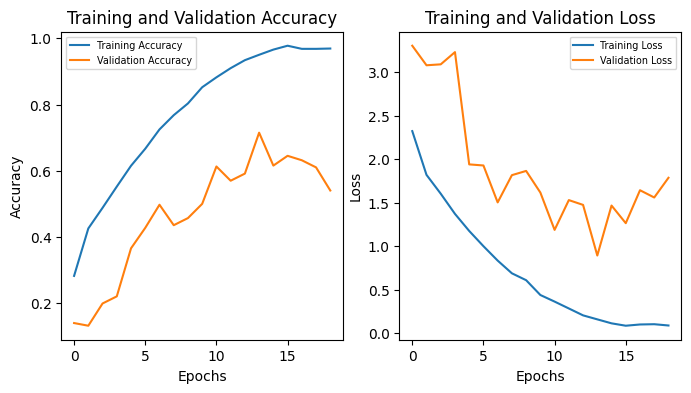

In [17]:
# Plot the Training History
plot_training_history(history)

In [28]:
trainingCSV, tensorBoardLogs, ModelBestsave = trainingLogPath
print("Training csv Logs: ", trainingCSV)
print("TensorBoard Logs: ", tensorBoardLogs)
print("Model Best Save: ", ModelBestsave)

print_accuracy_stats(model=ModelBestsave, ds=Train_scaled, class_names=classNames, typeOfData="Train")
print_accuracy_stats(model=ModelBestsave, ds=Val_scaled, class_names=classNames, typeOfData="Validation")
print_accuracy_stats(model=ModelBestsave, ds=Test_scaled, class_names=classNames, typeOfData="Test")

Training csv Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_20250223-170750\deep_Gap_BN_DP_Reg_model_20250223-170750.log
TensorBoard Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_tb_logs_20250223-170750
Model Best Save:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\model_save_20250223-170750\deep_Gap_BN_DP_Reg_model_best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step

Train Metrics:
Accuracy: 14.21%
Precision: 0.14
Recall: 0.14
F1 Score: 0.14

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Validation Metrics:
Accuracy: 10.75%
Precision: 0.10
Recall: 0.11
F1 Score: 0.11

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Test Metrics:
Accuracy: 16.42%
Precision: 0.16
Recall: 0.16
F1 Score: 0.16



#### Add regularization to the previous model

In [19]:

# Add regularization to the model
def create_deep_gap_bn_dp_reg_model(model_name="cnn_Model"):

    regularizers = tf.keras.regularizers.l2(0.001)

    # Input Layer
    inpLayer = layers.Input(shape=(height, width, channels))
    # conv unit 1
    conv2D_1 = layers.Conv2D(filters=16, kernel_size=(3, 3), padding="same", kernel_regularizer=regularizers) (inpLayer)
    actReli_1 = layers.Activation("relu") (conv2D_1)
    bn_1 = layers.BatchNormalization() (actReli_1)
    maxPool_1 = layers.MaxPooling2D() (bn_1)
 
    # conv unit 2
    conv2D_2 = layers.Conv2D(filters=32, kernel_size=(3, 3), padding="same", kernel_regularizer=regularizers) (maxPool_1)
    actReli_2 = layers.Activation("relu") (conv2D_2)
    bn_2 = layers.BatchNormalization() (actReli_2)
    maxPool_2 = layers.MaxPooling2D() (bn_2)

    # conv unit 3
    conv2D_3 = layers.Conv2D(filters=64, kernel_size=(3, 3), padding="same", kernel_regularizer=regularizers) (maxPool_2)
    actReli_3 = layers.Activation("relu") (conv2D_3)
    bn_3 = layers.BatchNormalization() (actReli_3)
    maxPool_3 = layers.MaxPooling2D() (bn_3)

    # conv unit 4
    conv2D_4 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same", kernel_regularizer=regularizers) (maxPool_3)
    actReli_4 = layers.Activation("relu") (conv2D_4)
    bn_4 = layers.BatchNormalization() (actReli_4)
    maxPool_4 = layers.MaxPooling2D() (bn_4)

    # conv unit 5
    conv2D_5 = layers.Conv2D(filters=128, kernel_size=(3, 3), padding="same", kernel_regularizer=regularizers) (maxPool_4)
    actReli_5 = layers.Activation("relu") (conv2D_5)
    bn_5 = layers.BatchNormalization() (actReli_5)
    maxPool_5 = layers.MaxPooling2D() (bn_5)

    # Global Average Pooling
    gapLayer = layers.GlobalAveragePooling2D() (maxPool_5)

    # Dense Layers
    dense_1 = layers.Dense(units=256, activation='relu', kernel_regularizer=regularizers) (gapLayer)
    bn_6 = layers.BatchNormalization() (dense_1)
    dropOut_1 = layers.Dropout(0.25) (dense_1)

    # output layer
    output = layers.Dense(units=len(classNames), activation='softmax') (dropOut_1)

    model = keras.Model(inputs=inpLayer, outputs=output, name=model_name)
    return model

In [20]:
modelName="deep_Gap_BN_DP_Reg_model"

# create Model
deep_gap_bn_dp_reg_model = create_deep_gap_bn_dp_reg_model(model_name=modelName)
imageName = modelName + ".png"
img=keras.utils.plot_model(deep_gap_bn_dp_reg_model, to_file=imageName, show_shapes=True)

# start Model Training
history, trainingLogPath = start_model_training(model=deep_gap_bn_dp_reg_model,
                               model_name=modelName,
                               train_data=Train_scaled,
                               val_data=Val_scaled,
                               epochs=50,
                               useCSVLogger=True,
                               useTensorBoard=True,
                               modelChkpoint=True,
                               earlyStopping=True,
                               lrScheduler=True)

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 14s 119ms/step - accuracy: 0.2905 - loss: 2.5784 - val_accuracy: 0.1398 - val_loss: 3.1763 - learning_rate: 0.0010
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.4720 - loss: 2.0208 - val_accuracy: 0.1694 - val_loss: 3.4987 - learning_rate: 0.0010
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.5344 - loss: 1.7924 - val_accuracy: 0.2634 - val_loss: 2.5801 - learning_rate: 0.0010
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 119ms/step - accuracy: 0.6151 - loss: 1.5746 - val_accuracy: 0.3333 - val_loss: 2.3993 - learning_rate: 0.0010
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.6677 - loss: 1.4024 - val_accuracy: 0.4328 - val_loss: 2.0159 - learning_rate: 0.0010
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 12s 123ms/step - accuracy: 0.7002 - loss: 1.2976 - val_accuracy: 0.4489 - val_loss: 1.9251 - learning_rate: 0.0010
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.7504 - loss: 1.

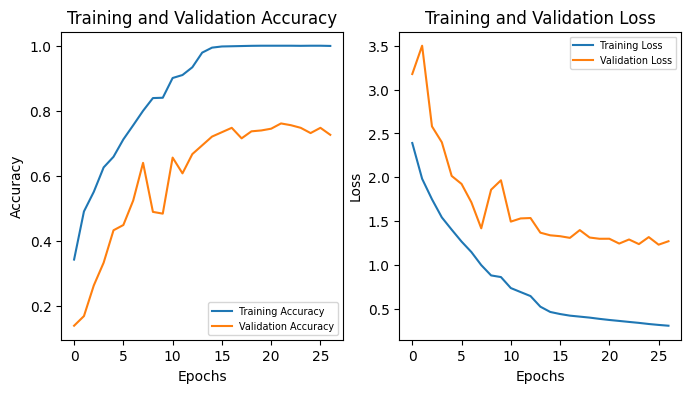

In [21]:
# Plot the Training History
plot_training_history(history)

In [31]:
trainingCSV, tensorBoardLogs, ModelBestsave = trainingLogPath
print("Training csv Logs: ", trainingCSV)
print("TensorBoard Logs: ", tensorBoardLogs)
print("Model Best Save: ", ModelBestsave)

print_accuracy_stats(model=ModelBestsave, ds=Train_scaled, class_names=classNames, typeOfData="Train")
print_accuracy_stats(model=ModelBestsave, ds=Val_scaled, class_names=classNames, typeOfData="Validation")
print_accuracy_stats(model=ModelBestsave, ds=Test_scaled, class_names=classNames, typeOfData="Test")

Training csv Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_20250223-170750\deep_Gap_BN_DP_Reg_model_20250223-170750.log
TensorBoard Logs:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\deep_Gap_BN_DP_Reg_model_tb_logs_20250223-170750
Model Best Save:  c:\Study\gitRepo\CV_Amazon_Cloth_Classify\notebooks\logs\model_save_20250223-170750\deep_Gap_BN_DP_Reg_model_best_model.keras
96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step

Train Metrics:
Accuracy: 14.50%
Precision: 0.15
Recall: 0.15
F1 Score: 0.15

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Validation Metrics:
Accuracy: 13.44%
Precision: 0.13
Recall: 0.13
F1 Score: 0.13

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Test Metrics:
Accuracy: 13.49%
Precision: 0.13
Recall: 0.13
F1 Score: 0.13




Test Metrics:
Accuracy: 0.7625

Macro-averaged metrics:
Precision: 0.7608
Recall: 0.7246
F1-score: 0.7374

Weighted-averaged metrics:
Precision: 0.7658
Recall: 0.7625
F1-score: 0.7599

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.62        32
           1       0.79      0.79      0.79        14
           2       0.79      0.69      0.74        49
           3       0.65      0.62      0.64        24
           4       0.87      0.82      0.84        49
           5       0.60      0.72      0.66        29
           6       0.77      0.77      0.77        26
           7       0.79      0.76      0.78        25
           8       0.88      0.58      0.70        12
           9       0.78      0.93      0.85        81

    accuracy                           0.76       341
   macro avg       0.76      0.72      0.74       341
weighted avg       0.77      0.76      0.76       341



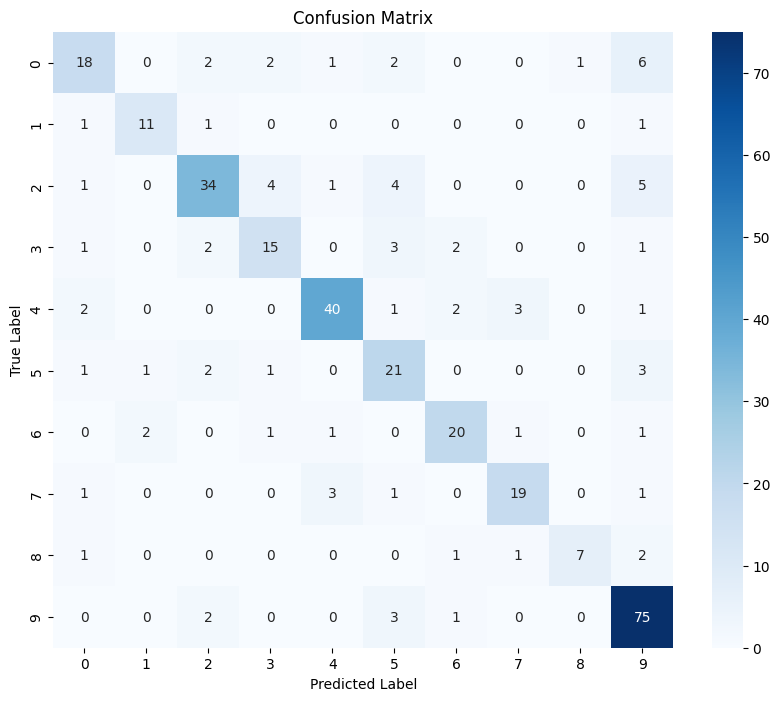

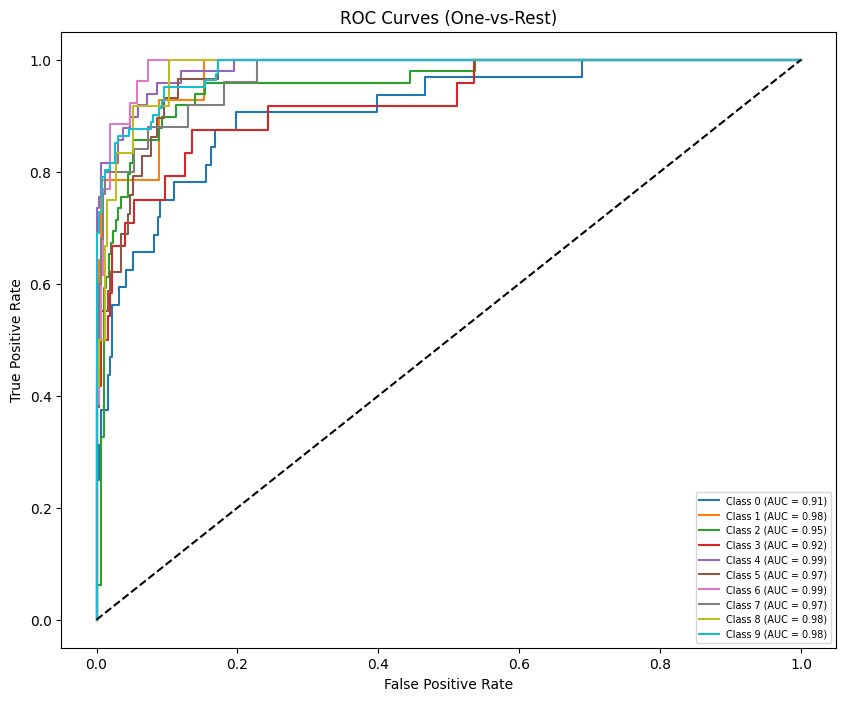

{'accuracy': 0.7624633431085044,
 'precision_macro': 0.7607606218772801,
 'recall_macro': 0.7246046326871449,
 'f1_macro': 0.7374386111598674,
 'precision_weighted': 0.7657824587455773,
 'recall_weighted': 0.7624633431085044,
 'f1_weighted': 0.7598968914939094,
 'confusion_matrix': array([[18,  0,  2,  2,  1,  2,  0,  0,  1,  6],
        [ 1, 11,  1,  0,  0,  0,  0,  0,  0,  1],
        [ 1,  0, 34,  4,  1,  4,  0,  0,  0,  5],
        [ 1,  0,  2, 15,  0,  3,  2,  0,  0,  1],
        [ 2,  0,  0,  0, 40,  1,  2,  3,  0,  1],
        [ 1,  1,  2,  1,  0, 21,  0,  0,  0,  3],
        [ 0,  2,  0,  1,  1,  0, 20,  1,  0,  1],
        [ 1,  0,  0,  0,  3,  1,  0, 19,  0,  1],
        [ 1,  0,  0,  0,  0,  0,  1,  1,  7,  2],
        [ 0,  0,  2,  0,  0,  3,  1,  0,  0, 75]])}

In [42]:
testModel = tf.keras.models.load_model(ModelBestsave)
calculate_multiclass_metrics(model=testModel, test_ds=Test_scaled, num_classes=10)